# Phase 5 — Feature Engineering

## NYC Real Estate Price Prediction

### Overview

Feature engineering transforms cleaned raw variables into meaningful metrics that improve **property analysis, investment analysis, and dashboard functionality**.

In this phase, we create features that describe:

- Property value relative to living area
- Estimated rental return
- Property size
- Investment attractiveness

A key consideration throughout this notebook is **target leakage**. Since `listing_price` is the target variable for the price prediction model, any feature that directly uses `listing_price` is suitable for analysis or dashboard use, but should **not** be used as a model input.

### Features Created

| Feature | Purpose | Model Training |
|---|---|---|
| `price_per_sqft` | Compare property prices relative to size | ❌ Exclude |
| `annual_rent` | Estimate annual rental income | ❌ Exclude |
| `rental_yield` | Estimate rental return | ❌ Exclude |
| `property_size_category` | Segment properties by size | ✅ Potentially usable |
| `tax_assessment_ratio` | Compare assessed value with listing price | ❌ Exclude |
| `investment_score` | Rank properties for investment analysis | ❌ Exclude |
| `investment_rating` | Convert the investment score into categories | ❌ Exclude |

> **Important:** The investment-related features in this notebook are analytical/dashboard features. They are not intended to improve the price prediction model through information derived from the target variable.

### Expected Outcome

By the end of this notebook, the feature-engineered dataset will be saved for use by the dashboard and the next machine learning phase.

## 1. Import Libraries and Load the Dataset

In [6]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:


df = pd.read_csv("/content/final_cleaned_zillow.csv")

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (1892, 25)


,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,home_type,days_on_zillow,listing_status,zpid,tax_assessed_value,clean_address,property_key,zestimate_missing,tax_assessed_missing,price_per_sqft,price_outlier,price_vs_zestimate,price_zestimate_ratio,rent_missing,tax_missing
0,"572 Louisiana Avenue #1, Brooklyn, NY 11239",11239,2.00,2.00,"1,017.00",40.65,-73.89,"250,000.00","3,550.00","856,400.00",CONDO,24,forSale,30775866,"570,294.00",572 LOUISIANA AVENUE BROOKLYN NY 11239,30775866,0,0,245.82,0,"-606,400.00",0.29,0,0
1,"2183 Ocean Ave #4A, Brooklyn, NY 11229",11229,1.00,1.00,541.00,40.61,-73.95,"485,000.00","2,489.00","473,800.00",CONDO,16,forSale,463914912,"817,000.00",2183 OCEAN AVE BROOKLYN NY 11229,463914912,0,1,896.49,0,"11,200.00",1.02,0,0
2,"8885 15th Ave, Brooklyn, NY 11228",11228,4.00,3.00,"2,060.00",40.61,-74.02,"1,299,000.00","5,015.00","1,315,600.00",SINGLE_FAMILY,4,forSale,30714518,"1,320,000.00",8885 15TH AVE BROOKLYN NY 11228,30714518,0,0,630.58,0,"-16,600.00",0.99,0,0
3,"300 Milford St, Brooklyn, NY 11208",11208,3.00,2.00,"1,232.00",40.67,-73.88,"595,000.00","3,574.00","602,800.00",SINGLE_FAMILY,29,forSale,30640361,"729,000.00",300 MILFORD ST BROOKLYN NY 11208,30640361,0,0,482.95,0,"-7,800.00",0.99,0,0
4,"2711 Avenue X Unit F2, Brooklyn, NY 11235",11235,2.00,1.00,"1,000.00",40.70,-73.97,"345,000.00","3,056.00","350,500.00",MULTI_FAMILY,20,forSale,463826019,"817,000.00",2711 AVENUE X UNIT F2 BROOKLYN NY 11235,463826019,0,1,345.00,0,"-5,500.00",0.98,0,0


In [8]:
# Verify the columns required for this phase are available.

required_columns = [
    "listing_price",
    "living_area",
    "rent_estimate",
    "tax_assessed_value",
    "zip_code",
]

missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


## 2. Feature 1 — Price Per Square Foot

`price_per_sqft` measures the listing price relative to the property's living area.

### Formula

`price_per_sqft = listing_price / living_area`

This metric is useful for comparing properties of different sizes and identifying relatively expensive or inexpensive properties within the dataset.

### Target Leakage

This feature directly uses `listing_price`, which is the prediction target. Therefore, it will be used for **EDA and dashboard analysis only** and excluded from model training.

In [9]:
# Calculate price per square foot only when living_area is positive.
# Invalid or zero living-area records cannot produce a meaningful value.

df["price_per_sqft"] = np.where(
    df["living_area"] > 0,
    df["listing_price"] / df["living_area"],
    np.nan,
)

print("Price per square foot calculated.")

Price per square foot calculated.


In [10]:
# Review the distribution of the engineered feature.

df["price_per_sqft"].describe()

,price_per_sqft
count,"1,892.00"
mean,631.88
std,"1,719.58"
min,2.91
25%,401.57
50%,519.42
75%,674.42
max,"59,523.81"


In [11]:
# Check for missing and infinite values.

print("Missing price_per_sqft:", df["price_per_sqft"].isna().sum())
print("Infinite price_per_sqft:", np.isinf(df["price_per_sqft"]).sum())

Missing price_per_sqft: 0
Infinite price_per_sqft: 0


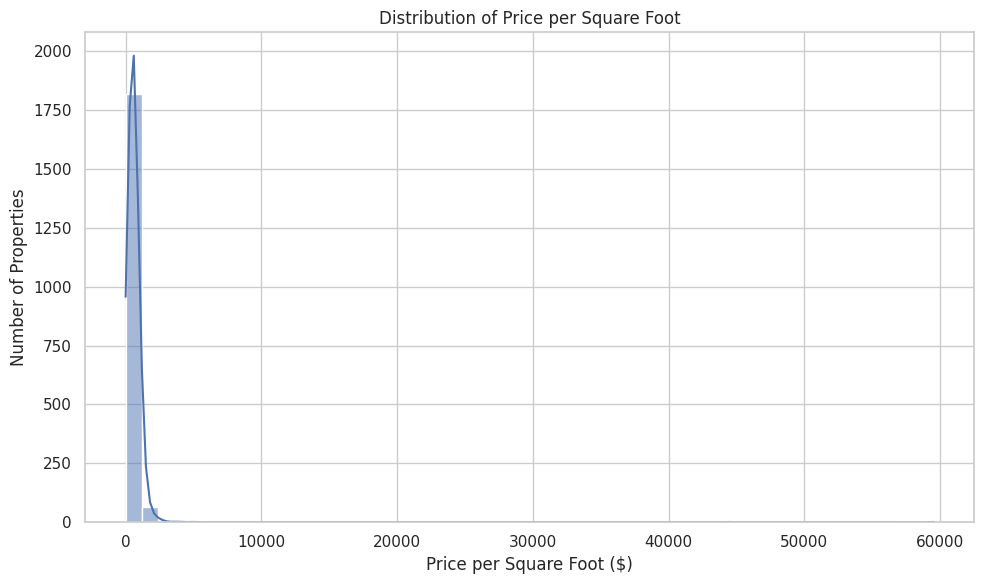

In [12]:
# Visualize the distribution of price per square foot.
# The raw distribution may contain extreme values, which are not automatically removed
# because high-value properties can represent legitimate NYC listings.

plt.figure(figsize=(10, 6))

sns.histplot(
    df["price_per_sqft"].dropna(),
    bins=50,
    kde=True,
)

plt.title("Distribution of Price per Square Foot")
plt.xlabel("Price per Square Foot ($)")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

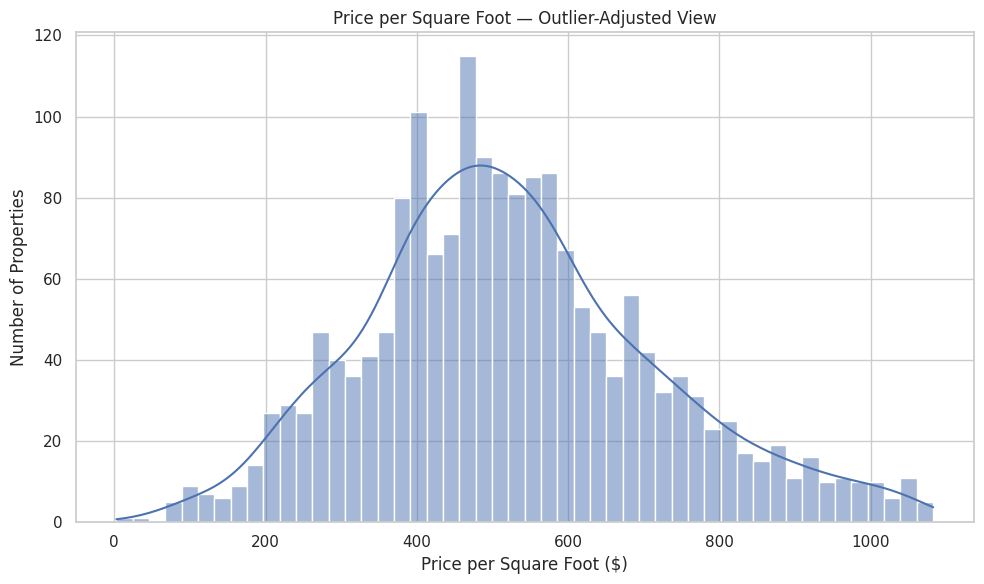

In [13]:
# Create an outlier-adjusted view for visualization only.
# This does NOT remove records from the main dataset.

q1 = df["price_per_sqft"].quantile(0.25)
q3 = df["price_per_sqft"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_sqft_plot = df[
    df["price_per_sqft"].between(lower_bound, upper_bound)
]

plt.figure(figsize=(10, 6))

sns.histplot(
    price_sqft_plot["price_per_sqft"].dropna(),
    bins=50,
    kde=True,
)

plt.title("Price per Square Foot — Outlier-Adjusted View")
plt.xlabel("Price per Square Foot ($)")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

## 3. Feature 2 — Rental Yield

Rental yield estimates the annual rental income relative to the property's listing price.

### Formulas

`annual_rent = rent_estimate × 12`

`rental_yield = annual_rent / listing_price`

For dashboard readability, the yield is also represented as a percentage:

`rental_yield_percent = rental_yield × 100`

This feature is useful for the **Investment Analysis** section of the dashboard.

### Target Leakage

Because rental yield uses `listing_price`, it is an **analysis/dashboard feature only** and must not be used as an input to the price prediction model.

In [14]:
# Estimate annual rental income from the monthly rent estimate.

df["annual_rent"] = df["rent_estimate"] * 12

print("Annual rent feature created.")

Annual rent feature created.


In [15]:
# Calculate rental yield only for records with a positive listing price.

df["rental_yield"] = np.where(
    df["listing_price"] > 0,
    df["annual_rent"] / df["listing_price"],
    np.nan,
)

# Convert the ratio into a percentage for easier interpretation.
df["rental_yield_percent"] = df["rental_yield"] * 100

print("Rental yield features created.")

Rental yield features created.


In [16]:
# Inspect the rental-yield calculation.

df[
    [
        "listing_price",
        "rent_estimate",
        "annual_rent",
        "rental_yield_percent",
    ]
].head(10)

,listing_price,rent_estimate,annual_rent,rental_yield_percent
0,"250,000.00","3,550.00","42,600.00",17.04
1,"485,000.00","2,489.00","29,868.00",6.16
2,"1,299,000.00","5,015.00","60,180.00",4.63
3,"595,000.00","3,574.00","42,888.00",7.21
4,"345,000.00","3,056.00","36,672.00",10.63
5,"599,999.00","3,050.00","36,600.00",6.10
6,"948,000.00","3,929.00","47,148.00",4.97
7,"3,600.00","3,467.00","41,604.00","1,155.67"
8,"869,000.00","4,245.00","50,940.00",5.86
9,"3,499,999.00","2,705.00","32,460.00",0.93


In [17]:
# Review the rental-yield distribution.

df["rental_yield_percent"].describe()

,rental_yield_percent
count,"1,892.00"
mean,7.20
std,26.83
min,0.28
25%,3.78
50%,5.24
75%,7.44
max,"1,155.67"


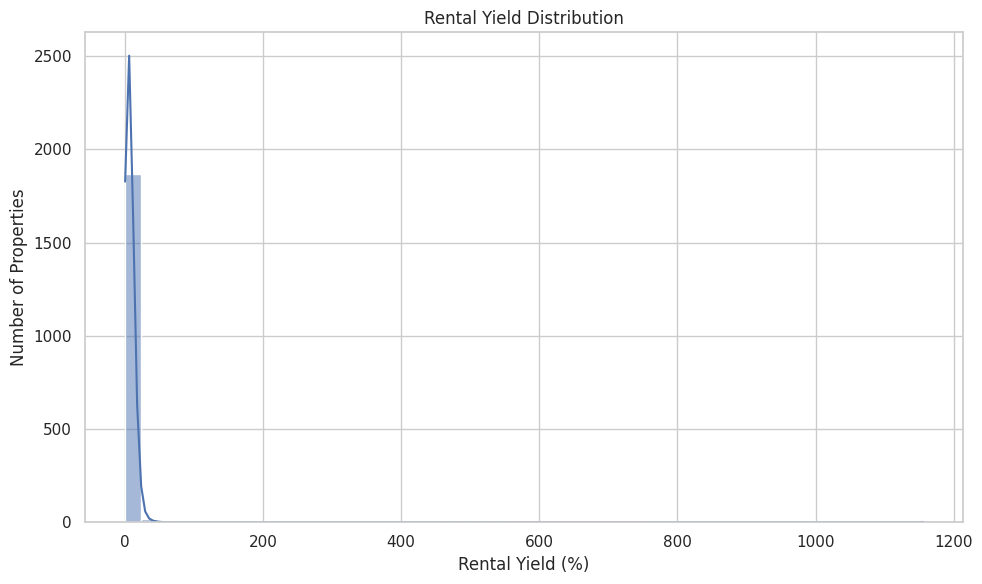

In [18]:
# Visualize rental yield.

plt.figure(figsize=(10, 6))

sns.histplot(
    df["rental_yield_percent"].dropna(),
    bins=50,
    kde=True,
)

plt.title("Rental Yield Distribution")
plt.xlabel("Rental Yield (%)")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

## 4. Feature 3 — Property Size Category

To make property-size comparisons easier, living area is converted into four categories.

| Living Area | Category |
|---:|---|
| `< 1,000 sq ft` | Small |
| `1,000–2,499 sq ft` | Medium |
| `2,500–4,999 sq ft` | Large |
| `5,000+ sq ft` | Luxury |

These categories provide an intuitive way to segment properties in the dashboard and can also be considered as a categorical model feature, provided they are encoded correctly during model training.

In [19]:
# Categorize properties based on living area.

def categorize_property_size(area):
    if pd.isna(area):
        return np.nan
    if area < 1000:
        return "Small"
    if area < 2500:
        return "Medium"
    if area < 5000:
        return "Large"
    return "Luxury"


df["property_size_category"] = df["living_area"].apply(
    categorize_property_size
)

print("Property size categories created.")

Property size categories created.


In [20]:
# Review the number of properties in each size category.

size_order = ["Small", "Medium", "Large", "Luxury"]

df["property_size_category"].value_counts().reindex(
    size_order,
    fill_value=0,
)

,count
property_size_category,
Small,390
Medium,1196
Large,265
Luxury,41


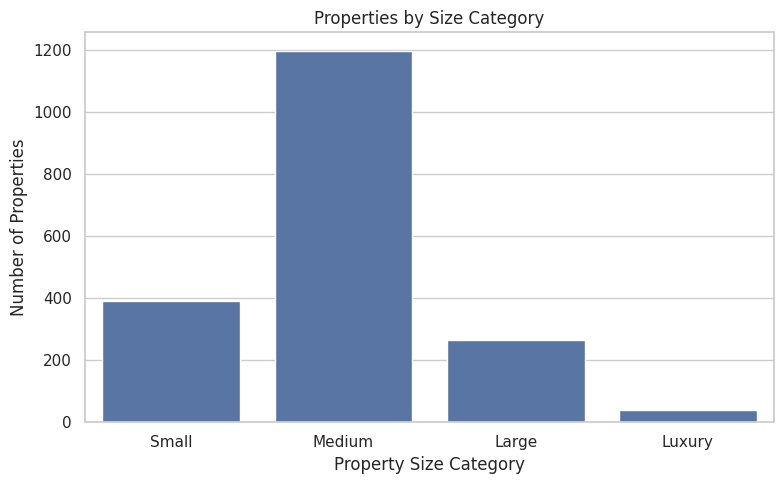

In [21]:
# Visualize the number of properties by size category.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="property_size_category",
    order=size_order,
)

plt.title("Properties by Size Category")
plt.xlabel("Property Size Category")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

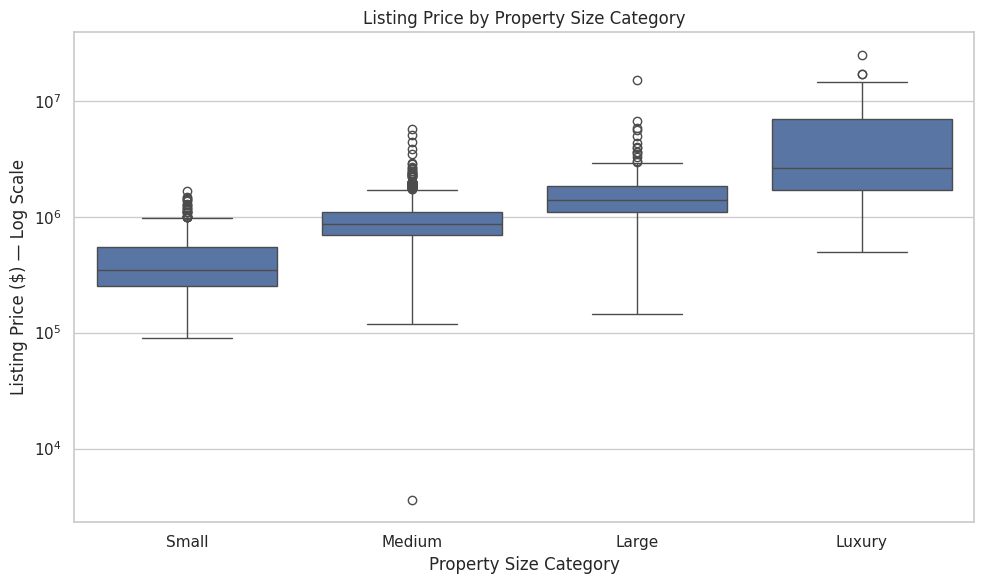

In [22]:
# Compare listing prices across property-size categories.
# A logarithmic y-axis helps because NYC listing prices are highly right-skewed.

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="property_size_category",
    y="listing_price",
    order=size_order,
)

plt.yscale("log")
plt.title("Listing Price by Property Size Category")
plt.xlabel("Property Size Category")
plt.ylabel("Listing Price ($) — Log Scale")
plt.tight_layout()
plt.show()

## 5. Feature 4 — Investment Score

The Investment Score is a custom **0–100 ranking** designed for the dashboard's Investment Analysis section.

The score combines four analytical components:

| Component | Weight | Interpretation |
|---|---:|---|
| Rental Yield | 35% | Higher estimated rental return is better |
| Price per Sqft | 25% | Lower relative price per square foot is better |
| Tax Assessment | 15% | Higher assessment-to-listing ratio receives a higher score |
| Location | 25% | Higher ZIP-level median listing price receives a higher score |

Because these metrics have different scales, each component is converted to a percentile-based score between approximately 0 and 100 before the weighted score is calculated.

> **Important:** This is a custom analytical ranking, not a financial recommendation. The current location component is a prototype based on ZIP-level median listing price and should not be interpreted as a complete measure of neighborhood quality.

### 5.1 Rental Yield Score

Higher rental yield receives a higher percentile score.

The percentile approach makes properties comparable even though rental yields have different absolute values.

In [23]:
# Convert rental yield into a 0–100 percentile-based score.
# Properties with higher rental yields receive higher scores.

df["rental_yield_score"] = (
    df["rental_yield"].rank(pct=True) * 100
)

print("Rental yield score created.")

Rental yield score created.


### 5.2 Price per Square Foot Score

For this investment-ranking prototype, a lower price per square foot is treated as more attractive.

The percentile ranking is therefore reversed:

- Lower price per sqft → higher score
- Higher price per sqft → lower score

This is a relative ranking, not a statement that a lower-priced property is automatically a better investment.

In [24]:
# Reverse the percentile rank so that lower price per square foot
# receives a higher investment score.

df["price_sqft_score"] = (
    (1 - df["price_per_sqft"].rank(pct=True)) * 100
)

print("Price-per-square-foot score created.")

Price-per-square-foot score created.


### 5.3 Tax Assessment Score

Instead of using the raw tax-assessed value, calculate an assessment ratio:

`tax_assessment_ratio = tax_assessed_value / listing_price`

This puts the tax assessment into context relative to the property's asking price.

Because this ratio uses `listing_price`, it is a dashboard/analysis metric and must be excluded from model training.

In [25]:
# Calculate the tax assessment ratio.

df["tax_assessment_ratio"] = np.where(
    df["listing_price"] > 0,
    df["tax_assessed_value"] / df["listing_price"],
    np.nan,
)

print("Tax assessment ratio created.")

Tax assessment ratio created.


In [26]:
# Convert the assessment ratio into a percentile-based score.

df["tax_value_score"] = (
    df["tax_assessment_ratio"].rank(pct=True) * 100
)

print("Tax value score created.")

Tax value score created.


### 5.4 Location Score

A latitude/longitude value alone does not provide a meaningful investment score. For this first version, location is represented by the **median listing price within each ZIP code**.

`zip_median_price` is calculated using the existing dataset and then converted into a percentile-based `location_score`.

This is intentionally a simple prototype. A future version could incorporate:

- ZIP-level rental yield
- Listing density
- Historical price appreciation
- Subway accessibility
- Schools
- Parks
- Neighborhood amenities

Higher ZIP-level median price does **not** automatically mean a better investment; it is simply the current location proxy used by this scoring framework.

In [27]:
# Calculate the median listing price for each ZIP code.
# transform() keeps the original number of rows and avoids an additional merge.

df["zip_median_price"] = (
    df.groupby("zip_code")["listing_price"]
      .transform("median")
)

print("ZIP-level median price calculated.")

ZIP-level median price calculated.


In [28]:
# Convert ZIP-level median price into a 0–100 percentile-based location score.

df["location_score"] = (
    df["zip_median_price"].rank(pct=True) * 100
)

print("Location score created.")

Location score created.


In [29]:
# Verify the location feature before combining the investment components.

df[
    ["zip_code", "listing_price", "zip_median_price", "location_score"]
].head(10)

,zip_code,listing_price,zip_median_price,location_score
0,11239,"250,000.00","452,000.00",11.28
1,11229,"485,000.00","350,000.00",4.89
2,11228,"1,299,000.00","1,280,000.00",91.01
3,11208,"595,000.00","809,500.00",37.76
4,11235,"345,000.00","527,000.00",13.66
5,11234,"599,999.00","899,000.00",70.03
6,11234,"948,000.00","899,000.00",70.03
7,11204,"3,600.00","1,294,800.00",91.65
8,11234,"869,000.00","899,000.00",70.03
9,11234,"3,499,999.00","899,000.00",70.03


### 5.5 Combine the Investment Components

The final Investment Score uses the following weights:

- Rental Yield: **35%**
- Price per Sqft: **25%**
- Tax Assessment: **15%**
- Location: **25%**

The result is a 0–100 ranking where higher values indicate stronger performance according to this project's scoring framework.

In [30]:
# Combine the four component scores using the predefined weights.

df["investment_score"] = (
    df["rental_yield_score"] * 0.35
    + df["price_sqft_score"] * 0.25
    + df["tax_value_score"] * 0.15
    + df["location_score"] * 0.25
)

# Round the final score for dashboard readability.
df["investment_score"] = df["investment_score"].round(1)

print("Investment score created.")

Investment score created.


In [31]:
# Review the distribution of the Investment Score.

df["investment_score"].describe()

,investment_score
count,"1,892.00"
mean,50.01
std,16.55
min,6.30
25%,38.30
50%,49.40
75%,61.70
max,97.80


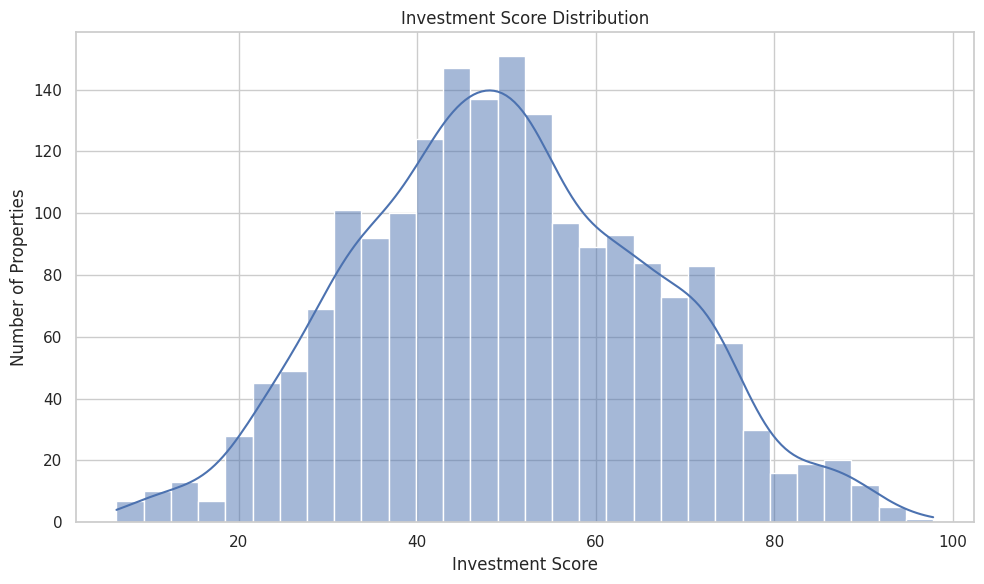

In [32]:
# Visualize the Investment Score distribution.

plt.figure(figsize=(10, 6))

sns.histplot(
    df["investment_score"].dropna(),
    bins=30,
    kde=True,
)

plt.title("Investment Score Distribution")
plt.xlabel("Investment Score")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

## 6. Investment Rating

A numeric score is useful for analysis, but a categorical rating is easier to interpret in a dashboard.

The score is mapped to five rating levels:

| Score | Rating |
|---:|---|
| 80–100 | Excellent |
| 65–79.9 | Good |
| 50–64.9 | Moderate |
| 35–49.9 | Below Average |
| < 35 | Poor |

These labels are descriptive categories created for this project and should not be interpreted as professional investment advice.

In [33]:
# Convert the numeric Investment Score into a dashboard-friendly rating.

def investment_rating(score):
    if pd.isna(score):
        return np.nan
    if score >= 80:
        return "Excellent"
    if score >= 65:
        return "Good"
    if score >= 50:
        return "Moderate"
    if score >= 35:
        return "Below Average"
    return "Poor"


df["investment_rating"] = df["investment_score"].apply(
    investment_rating
)

print("Investment ratings created.")

Investment ratings created.


In [34]:
# Review the highest-ranked properties.

investment_columns = [
    "address",
    "listing_price",
    "rental_yield_percent",
    "price_per_sqft",
    "location_score",
    "investment_score",
    "investment_rating",
]

df[
    investment_columns
].sort_values(
    "investment_score",
    ascending=False,
    na_position="last",
).head(20)

,address,listing_price,rental_yield_percent,price_per_sqft,location_score,investment_score,investment_rating
7,"1977 73rd Street #2, Brooklyn, NY 11204","3,600.00","1,155.67",2.91,91.65,97.80,Excellent
1048,"15517 Sanford Avenue #2E, Flushing, NY 11355","148,000.00",28.78,185.00,82.82,94.50,Excellent
1749,"21-15 33rd St #C2, Astoria, NY 11105","180,000.00",20.11,122.70,82.32,93.90,Excellent
967,"2167 33rd Street #3H, Astoria, NY 11105","165,000.00",25.82,206.25,82.32,93.70,Excellent
653,"1270 E 51st St APT 6M, Brooklyn, NY 11234","169,958.00",26.15,115.85,70.03,91.80,Excellent
39,"237 Hancock St APT 11, Brooklyn, NY 11216","400,000.00",15.32,272.67,98.71,91.70,Excellent
624,"1199 E 53rd St APT 6P, Brooklyn, NY 11234","200,000.00",21.34,136.33,70.03,91.30,Excellent
670,"1275 E 51st St APT 3C, Brooklyn, NY 11234","159,000.00",27.26,212.00,70.03,91.10,Excellent
194,"2020 E 41st St APT 1C, Brooklyn, NY 11234","100,000.00",27.46,210.53,70.03,90.70,Excellent
1746,"21-28 35th St APT 1H, Astoria, NY 11105","275,000.00",13.03,187.46,82.32,90.20,Excellent


In [35]:
# Check how many properties fall into each investment-rating category.

rating_order = [
    "Excellent",
    "Good",
    "Moderate",
    "Below Average",
    "Poor",
]

df["investment_rating"].value_counts().reindex(
    rating_order,
    fill_value=0,
)

,count
investment_rating,
Excellent,70
Good,306
Moderate,537
Below Average,615
Poor,364


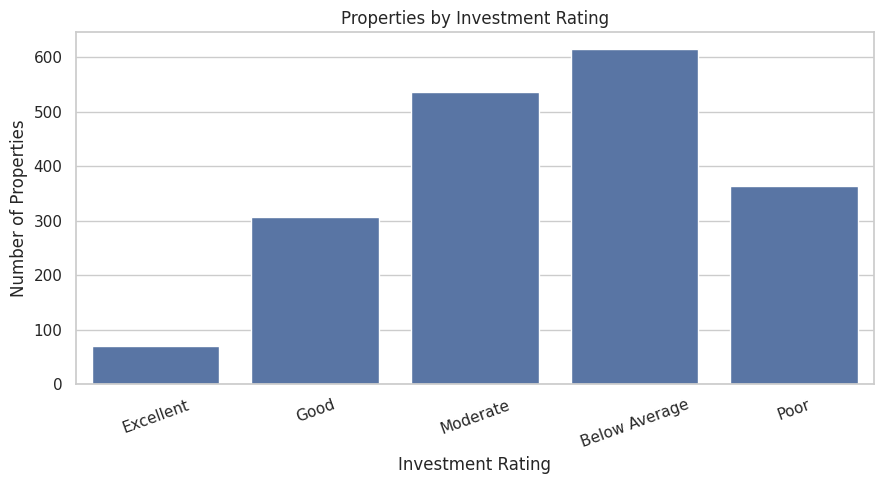

In [36]:
# Visualize the Investment Rating distribution.

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="investment_rating",
    order=rating_order,
)

plt.title("Properties by Investment Rating")
plt.xlabel("Investment Rating")
plt.ylabel("Number of Properties")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 7. Validate the Engineered Features

Before saving the dataset, verify that all expected features exist and inspect their missing-value counts.

Missing values are not automatically removed in this phase because some source variables, such as `rent_estimate` and `tax_assessed_value`, may legitimately be unavailable for certain properties.

In [37]:
# List all features created during this notebook.

engineered_features = [
    "price_per_sqft",
    "annual_rent",
    "rental_yield",
    "rental_yield_percent",
    "property_size_category",
    "tax_assessment_ratio",
    "rental_yield_score",
    "price_sqft_score",
    "tax_value_score",
    "zip_median_price",
    "location_score",
    "investment_score",
    "investment_rating",
]

print("Engineered features:")
for feature in engineered_features:
    print(f"- {feature}")

Engineered features:
- price_per_sqft
- annual_rent
- rental_yield
- rental_yield_percent
- property_size_category
- tax_assessment_ratio
- rental_yield_score
- price_sqft_score
- tax_value_score
- zip_median_price
- location_score
- investment_score
- investment_rating


In [38]:
# Inspect missing values in the engineered features.

feature_quality = (
    df[engineered_features]
    .isna()
    .sum()
    .to_frame("missing_values")
)

feature_quality["missing_percent"] = (
    feature_quality["missing_values"] / len(df) * 100
).round(2)

feature_quality

,missing_values,missing_percent
price_per_sqft,0,0.00
annual_rent,0,0.00
rental_yield,0,0.00
rental_yield_percent,0,0.00
property_size_category,0,0.00
tax_assessment_ratio,0,0.00
rental_yield_score,0,0.00
price_sqft_score,0,0.00
tax_value_score,0,0.00
zip_median_price,0,0.00


In [39]:
# Confirm that the Investment Score remains within the intended 0–100 range
# for records where all required components are available.

valid_scores = df["investment_score"].dropna()

print(f"Minimum Investment Score: {valid_scores.min():.1f}")
print(f"Maximum Investment Score: {valid_scores.max():.1f}")

assert valid_scores.between(0, 100).all(), (
    "Investment Score contains values outside the 0–100 range."
)

print("Investment Score validation passed.")

Minimum Investment Score: 6.3
Maximum Investment Score: 97.8
Investment Score validation passed.


## 8. Save the Feature-Engineered Dataset

The feature-engineered dataset is saved separately from the cleaned dataset so that the project maintains a clear data-processing pipeline.

This version is intended for:

- Streamlit dashboard analysis
- Investment analysis
- Future feature exploration
- Downstream modeling after leakage review

In [41]:
# Save the feature-engineered dataset to the processed-data directory.

output_path = "feature_engineered_zillow_dataset.csv"

df.to_csv(
    output_path,
    index=False
)

print(f"Saved feature-engineered dataset to: {output_path}")

Saved feature-engineered dataset to: feature_engineered_zillow_dataset.csv


## 9. Protect the Machine Learning Pipeline from Target Leakage

The goal of the next phase is to predict `listing_price`.

Several features created in this notebook directly or indirectly depend on `listing_price`:

- `price_per_sqft`
- `annual_rent` is not itself target-derived, but it is used to create `rental_yield`
- `rental_yield`
- `rental_yield_percent`
- `tax_assessment_ratio`
- `tax_value_score`
- `zip_median_price` is calculated from `listing_price`
- `location_score`
- `investment_score`
- `investment_rating`

These features should therefore be excluded from the price-prediction model.

`property_size_category` does not use the target and may be considered as a model feature after appropriate categorical encoding.

In [42]:
# Define features that must be excluded from the price prediction model
# because they directly or indirectly depend on listing_price.

leakage_features = [
    "price_per_sqft",
    "rental_yield",
    "rental_yield_percent",
    "tax_assessment_ratio",
    "tax_value_score",
    "zip_median_price",
    "location_score",
    "investment_score",
    "investment_rating",
]

model_df = df.drop(
    columns=leakage_features,
    errors="ignore",
)

target = "listing_price"

print(f"Model-ready dataframe shape: {model_df.shape}")
print(f"Target variable: {target}")
print("Leakage-prone analytical features excluded from model_df.")

Model-ready dataframe shape: (1892, 28)
Target variable: listing_price
Leakage-prone analytical features excluded from model_df.


In [43]:
# Confirm that none of the excluded leakage features remain in model_df.

remaining_leakage = [
    feature for feature in leakage_features
    if feature in model_df.columns
]

if remaining_leakage:
    raise ValueError(
        f"Leakage features still present in model_df: {remaining_leakage}"
    )

print("Target-leakage check passed.")

Target-leakage check passed.


## 10. Phase 5 Conclusion

Feature engineering is complete.

The dataset now includes analytical features for:

- Price-per-square-foot comparisons
- Rental-yield analysis
- Property-size segmentation
- Investment scoring and rating

The feature-engineered dataset has been saved for dashboard use, while target-derived features have been explicitly separated from the machine learning feature set.

### Key Takeaway

The most important principle in this phase is **feature usefulness without target leakage**. A feature can be valuable for business analysis while still being inappropriate for predictive modeling.

The next phase will focus on **model training and evaluation**, using only features that would realistically be available when predicting a property's listing price.